# Test d'hypothèse

On introduit l'hypothèse nulle $H_0$. C'est l'hypothèse faite par défaut qui reflète notre conception de l'étude. 
L'hypothèse alternative est notée $H_A$. 

### Exemple

Dans la vie courante $H_0$ peut être par exemple on possède moins de 10 paires de chaussures. L'hypothèse alternative $H_A$ on en possède plus que 10 paires.  

Attention : la formulation d'une hypothèse ne peut pas être vague. Par exemple " le trading instantanné est un bon moyen pour gagner de l'argent " cette hypothèse est assez vague pour être testée.

### Comment mettre en place un test

1- Formuler correctement l'hypothèse et son alternative

2- Identifier la statistique appropriée ainsi que sa loi en vérifiant que les conditions qu'on doit avoir sur les données sont vérifiées (normalité, stationnarité , etc).

3- Spécifier la signification du niveau $\alpha$.

4- A l'aide de $\alpha$ et de la loi de la statistique on doit calculer la valeur critique.

5- A partir des données il faut calculer le test statistique.

6- Comparer le test statistique obtenu sur les données à la valeur critique et décider d'accepter ou rejeter $H_0$.


### Tests bilatéraux et unilatéraux 

On donne des exemples : On s'intéresse si le rendement moyen de l'action Microsoft est positve ? Le paramètre qu'on teste est noté $\theta$ et la valeur proposée du paramètre est notée $\theta_0$ qui dans notre cas va être égale à 0.
    
1-  $H_0$ : $\theta=\theta_0$ versus $H_A$: $\theta\neq\theta_0$ 

2-  $H_0$ : $\theta\le\theta_0$ versus $H_A$: $\theta>\theta_0$ 

3-  $H_0$ : $\theta\ge \theta_0$ versus $H_A$: $\theta<\theta_0$ 

Dans cet exemple on teste le rendement moyen de MSFT $\theta=\mu_{MSFT}$. Comme on voudrait savoir si ce rendement est positif ou négatif on a $\theta_0=0$. La formulation 1- ci-dessus du test s'appelle un test bilatéral les deux autres formulations sont dites  unilatérales.  En pratique, le plus commun des tests c'est le test bilatéral. 

### Exemple de test bilatéral : 

On étudie les données de l'action MSFT entre 1/1/2015 et 1/1/2016

$H_0$ : la moyenne du rendement de l'action MSFT est 0

$H_A$ : la moyenne du rendement de l'action MSFT n'est pas 0

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
from datetime import datetime

C:\Users\lione\AppData\Local\Temp\ipykernel_42940\150107104.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pricing_sample=yf.download('MSFT', start, end).loc[:,'Close']
[*********************100%***********************]  1 of 1 completed

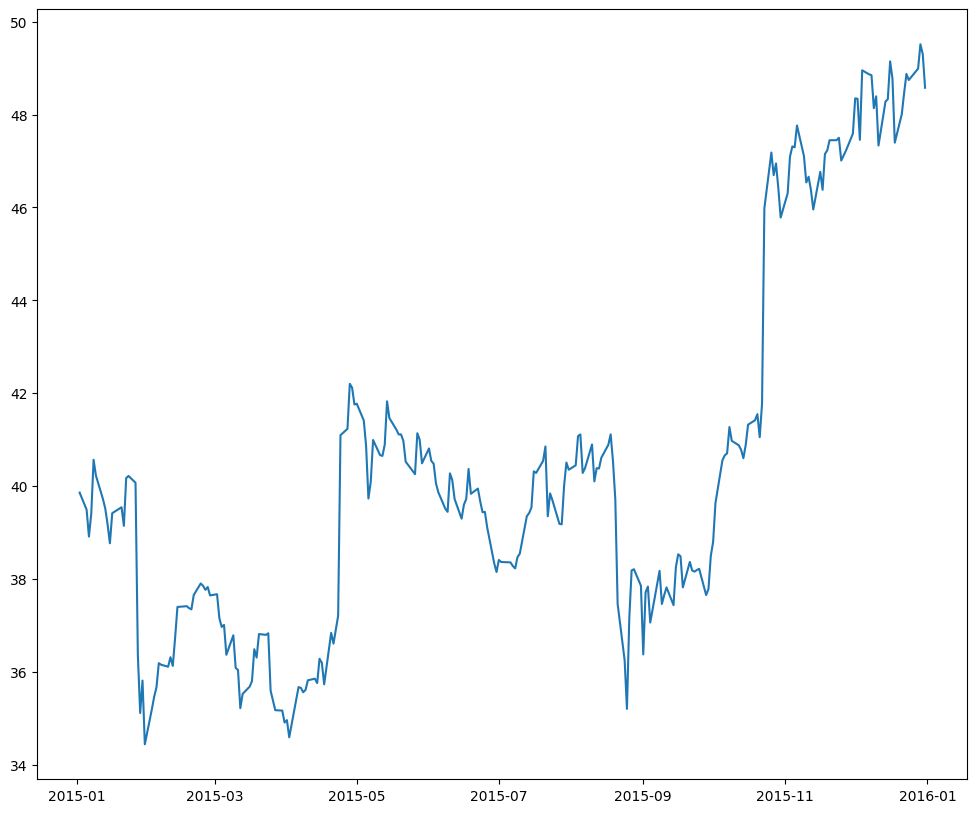

In [128]:
start, end = dt.datetime(2015, 1, 1), dt.datetime(2016, 1, 1)
pricing_sample=yf.download('MSFT', start, end).loc[:,'Close']

#transform it into returns
returns_sample = pricing_sample.pct_change()[1:].values

# plot it
plt.plot(pricing_sample)
#plt.ylabel('Price');

0.0009450236911948029
erreur_MC 0.002197714441018394
val_max_moy 0.003142738132213197
val_min_moy -0.0012526907498235911


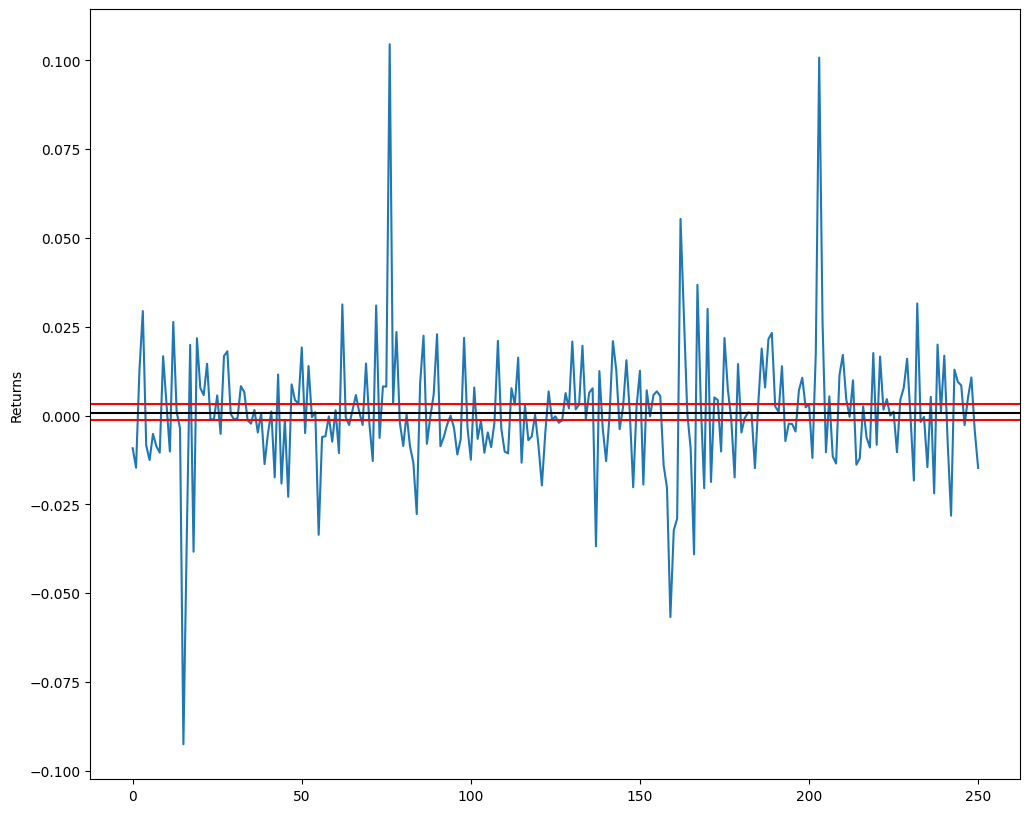

In [129]:
plt.plot( returns_sample)
plt.ylabel('Returns')
## Calculer la moyenne, l'erreur d'estimation et l'intervalle de confiance
print(np.mean(returns_sample))
erreur_MC=1.96*np.std(returns_sample)/np.sqrt(len(returns_sample))
print('erreur_MC', erreur_MC)
val_max_moy=np.mean(returns_sample)+erreur_MC
val_min_moy=np.mean(returns_sample)-erreur_MC
print('val_max_moy',val_max_moy )
print('val_min_moy',val_min_moy)
plt.axhline(val_max_moy,color='r')
plt.axhline(val_min_moy,color='r')
plt.axhline(0.0008384992490174008,color='k')

### Le z-test 

On identifie le test statistique approprié 


<div class="alert alert-block alert-info">
   $$\text{Test_Statistique}=\frac{\text{Statistique échantillon} - \text{Valeur du paramètre sous H0}}{\text{Erreur_standard}}$$
</div>



C'est la formule à utiliser pour le $z$-test.

Dans notre cas d'étude on utilise la moyenne de l'écahntillon ${\bar X}_{\mu}=\frac 1n\sum_{i=1}^n X_i $ comme "Statistique échantillon". On calcule l'erreur statndard :  $$\sigma_{\bar X}= \frac{\sigma}{\sqrt n}$$
Où $\sigma$ est l'écart type de l'échantillon et $n$ la taille de ce dernier.  On rappelle que si les $(X_i)_{1\le i\le n}$ sont i.i.d. alors $$\bar X_{\mu}=\frac 1n\sum_{i=1}^n X_i\longrightarrow \mathbb E(X_1)\;\; p.s.$$ quand $n\to\infty$ c'est la loi forte des grands nombres (LFGN).

On veut tester $H_0:= \mbox{ Le rendement moyen du stock Microsoft est 0}$ donc la " Valeur du paramètre sous $H_0$" est $\theta_0=0$. 

Donc le test statistique est donné par 
$$
\text{Test_Statistique}=\frac{\bar X_{\mu}-\theta_0}{\sigma_{\bar X}}=\sqrt n\Big(\frac{\bar X_{\mu}-0}{\sigma}\Big)
$$
Notons si la moyenne théorique (inconnue) de $X_1$ est égale à 0 (i.e. $H_0$ est vraie) alors d'après le TLC on a 
$$
\text{Test_Statistique}=\sqrt n\Big(\frac{\bar X_{\mu}-0}{\sigma}\Big)\sim N(0,1) \text{ quand } n\to \infty
$$
Donc pour accepter ou rejeter $H_0$ on applique le test de la loi normale appelé aussi $z$-test
avec un niveau de signification $\alpha=0.05$. C'est un test bilatéral. 

In [130]:
## Calculer test_statistic
n = len(returns_sample)
#print(n)
#print(returns_sample)
test_statistic = np.sqrt(n)*(returns_sample.mean() - 0) /(returns_sample.std())
print('z-test statistic: ', test_statistic)

# test_stat appartient [-1.96;1.96] avec 1-0.05=0.95 de niveau de confiance
#z-test valeur critique 1.96

z-test statistic:  0.8428057804832485


La valeur $0.74449531394807981 \in [-1.96;1.96]$ donc on n'est pas en mesure de rejeter l'hypothèse $H_0$, selon le $z$-test. 


#### Choix de la valeur critique

On se fixe un niveau de signification $\alpha=0.05$.

$\bullet$ **Test unilatéral.** Si on teste $H_0$ : $\theta\le \theta_0$ la valeur critique c'est 
$$ 
z_{0.05}=F^{-1}_{\text{Normale}}(1- 0.05)=F^{-1}_{\text{Normale}}(0.95)
$$

où $x\mapsto F_{\text{Normale}}(x)$ est la fonction de répartition d'une loi normale $N(0,1)$.

CC.: On rejète $H_0$ si la valeur du Test_Statistique$> z_{0.05}$




In [131]:
import scipy.stats as stats

z_critic=-stats.norm.ppf(0.95, 0, 1)

print('z_{0.05} is : ', z_critic)

if (test_statistic>z_critic) :
    print('On rejète H_0')
else:
     print('On accepte H_0')

z_{0.05} is :  -1.6448536269514722
On rejète H_0


$\bullet$ **Test unilatéral.** Si on teste $H_0$ : $\theta\ge \theta_0$ la valeur critique c'est 
$$ 
z_{0.05}=-F^{-1}_{\text{Normale}}(1- 0.05)=-F^{-1}_{\text{Normale}}(0.95)
$$

où $x\mapsto F_{\text{Normale}}(x)$ est la fonction de répartition d'une loi normale $N(0,1)$.

CC.: On rejète $H_0$ si la valeur du Test_Statistique$< -z_{0.05}$

In [132]:
z_critic=-stats.norm.ppf(0.95, 0, 1)

print('z_{0.05} is : ', z_critic)

if (test_statistic<z_critic) :
    print('On rejète H_0')
else:
     print('On accepte H_0')

z_{0.05} is :  -1.6448536269514722
On accepte H_0


$\bullet$ **Test bilatéral.** On a deux points critiques : 
Comme $\alpha=0.05=\mathbb P(\text{rejeter } H_0 \text{ quand } H_0 \text{ est vraie })$, on partage $0.05$ par deux de sorte que les deux points de rejet critiques sont 
$z_{0.025}$ et $-z_{0.025}$.

Si on teste $H_0$ : $\theta= \theta_0$ les deux valeurs critiques sont 
$$ 
z_{0.025}=F^{-1}_{\text{Normale}}(1- 0.025)=F^{-1}_{\text{Normale}}(0.975)
$$

où $x\mapsto F_{\text{Normale}}(x)$ est la fonction de répartition d'une loi normale $N(0,1)$.

CC.: On rejète $H_0$ si la valeur du Test_Statistique$< -z_{0.25}$ ou Test_Statistique$> z_{0.25}$

In [133]:
z_critic_1=stats.norm.ppf(0.975, 0, 1)
z_critic_2=-z_critic_1

print('z_{0.025} is : ', z_critic_1)
print('-z_{0.025} is : ', z_critic_2)

if (test_statistic<z_critic_2 or test_statistic>z_critic_1  ) :
    print('On rejète H_0')
    
else:
     print('On ne rejète pas H_0')

z_{0.025} is :  1.959963984540054
-z_{0.025} is :  -1.959963984540054
On ne rejète pas H_0


### t-Test (Student) 

t-Test fait appel à la loi de Student pour comparer deux moyennes de deux échantillons différents

1- $H_0$: $\mu_1-\mu_2=\theta_0$, $H_A$: $\mu_1-\mu_2\neq \theta_0$

2- $H_0$: $\mu_1-\mu_2\le\theta_0$, $H_A$: $\mu_1-\mu_2> \theta_0$

3- $H_0$: $\mu_1-\mu_2\ge\theta_0$, $H_A$: $\mu_1-\mu_2 <\theta_0$

On supposera dans cet exemple que $\mu_1,\mu_2$ sont respectivement les moyennes de rendement de 'SPY' (indice boursier américain) et 'AAPL' (Apple) et $\theta_0$ est le paramètre qu'on veut tester. On va tester si ces deux indices ont les mêmes moyennes de rendement.

$H_0$ : $\mu_1-\mu2=0$, 

###### Les variances des deux échantillons sont égales

Sous cette hypothèse le test statstique est donné par 

$$
\text{Test_Statistique}= \frac{(\bar X_{\mu_1}-\bar X_{\mu_2})-(\mu_1-\mu_2)}{\Big(\frac{S^2_p}{n_1}+\frac{S^2_p}{n_2}\Big)^{1/2}}
$$
cette quantité est égale dans notre, sous $H_0$ on a ($\theta_0=0$)
$$
\text{Test_Statistique}= \frac{(\bar X_{\mu_1}-\bar X_{\mu_2})}{\Big(\frac{S^2_p}{n_1}+\frac{S^2_p}{n_2}\Big)^{1/2}}
$$

avec 

$$
S^2_p=\frac{(n_1-1){\bar{\sigma_1}}^2+(n_2-1){\bar{\sigma_2}}^2}{n_1+n_2-2}
$$

c'est l'estimateur sans biais de la variance commune et $n_1$, $n_2$, représentant les tailles respectives des deux échantillons (SPY et AAPL). 

Dans ce cas, sous $H_0$ le test statstique est comparé à une loi de student avec $n_1+n_2-2$ degré de liberté :
$t(n_1+n_2-2)$.

###### Les variances des deux échantillons ne sont pas égales

Sous cette hypothèse le test statstique est donné par 

$$
\text{Test_Statistique}= \frac{(\bar X_{\mu_1}-\bar X_{\mu_2})-(\mu_1-\mu_2)}{\Big(\frac{{\bar{\sigma_1}}^2}{n_1}+ \frac{{\bar{\sigma_2}}^2}{n_2}\Big)^{1/2}}
$$
cette quantité est égale sous $H_0$ dans notre exemple à  ($\theta_0=0$)
$$
\text{Test_Statistique}=\frac{(\bar X_{\mu_1}-\bar X_{\mu_2})}{\Big(\frac{{\bar{\sigma_1}}^2}{n_1}+ \frac{{\bar{\sigma_2}}^2}{n_2}\Big)^{1/2}}
$$
avec ${\bar{\sigma_1}}^2$ et ${\bar{\sigma_2}}^2$ sont respectivement les variances empiriques des deux échantuillons. 

Cette quantité est comparée à une loi de student avec $d_f$ degré de liberté  $ t(d_f)$ où 


$$
d_f:=\frac{\Big(\frac{{\bar{\sigma_1}}^2}{n_1}+ \frac{{\bar{\sigma_2}}^2}{n_2}\Big)^{2}}{\frac{\Big(\frac{{\bar{\sigma_1}}^2}{n_1}\Big)^2}{n_1}+\frac{\Big(\frac{{\bar{\sigma_2}}^2}{n_2}\Big)^2}{n_2}}
$$

$\bullet$ **Test unilateral.** $\mu_1-\mu_2\le\theta_0$ la  $p$-value$=1-F_{t}(\text{Test_Statistique})$

$\bullet$ **Test unilateral.** $\mu_1-\mu_2\ge\theta_0$ la $p$-value$=F_{t}(\text{Test_Statistique})$

$\bullet$ **Test bilateral.** $\mu_1-\mu_2=\theta_0$ la $p$-value$=2\Big(1-F_{t}(\text{Test_Statistique})\Big)$


La $p$-value représente le niveau de signification minimum à partir duquel on peut rejeter l'hypothèse nulle $H_0$

###### Règle de rejet :

Si la $p$-value est plus petite que $\alpha$ le niveau de signfication choisi on rejète $H_0$, si c'est plus grand 
on ne rejette pas $H_0$.

###### Remarque 
Le $t$-test peut s'appliquer avec un seul échantillon on supposant que le deuxième est nul. Donc on peut appliquer 
le $t$-test pour comparer la moyenne de rendement de 'MSFT' à la valeur 0 (Test bilatéral). Dans ce cas 

$$
\text{Test_Statistique}= \frac{\bar X_{\mu}}{\Big(\frac{{\bar{\sigma}}^2}{n}\Big)^{1/2}}=\sqrt{n}\frac{\bar X_{\mu}}{{\bar{\sigma}}}
$$

Comme on n'a qu'une seule variance la $p$-value est calculée avec $t(n-1)$ car on rappelle que dans cet exemple
$n_1=n$ et $n_2=0$.




In [134]:
from scipy.stats import t 

n = len(returns_sample)
test_statistic = np.sqrt(n)*(returns_sample.mean() - 0) /(returns_sample.std())

p_val = 2 * (1 - t.cdf(test_statistic, n - 1))
print('P-value is: ', p_val)

#p_value= 0.45 >alpha=0.0.5 on dit qu'on est pas capable de rejeter H0

P-value is:  0.40014267388122793


La valeur $0.45699978437242383 > \alpha:=0.05$ donc on n'est pas en mesure de rejeter l'hypothèse $H_0$, selon le $t$-test. 

On conclut que selon $t$-test la moyenne des rendements de 'MSFT'  n'est pas significativement differente de 0.  

Donc le $t$-test consolide le $z$-test.

C:\Users\lione\AppData\Local\Temp\ipykernel_42940\2026931193.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pricing_sample=yf.download(symbol_list, start, end).loc[:,'Close']
[*********************100%***********************]  2 of 2 completed

Ticker          AAPL       SPY
Date                          
2015-01-05 -0.028171 -0.018060
2015-01-06  0.000094 -0.009419
2015-01-07  0.014022  0.012461
2015-01-08  0.038423  0.017745
2015-01-09  0.001072 -0.008013
...              ...       ...
2015-12-24 -0.005340 -0.001650
2015-12-28 -0.011201 -0.002285
2015-12-29  0.017974  0.010672
2015-12-30 -0.013059 -0.007088
2015-12-31 -0.019195 -0.010003

[251 rows x 2 columns]


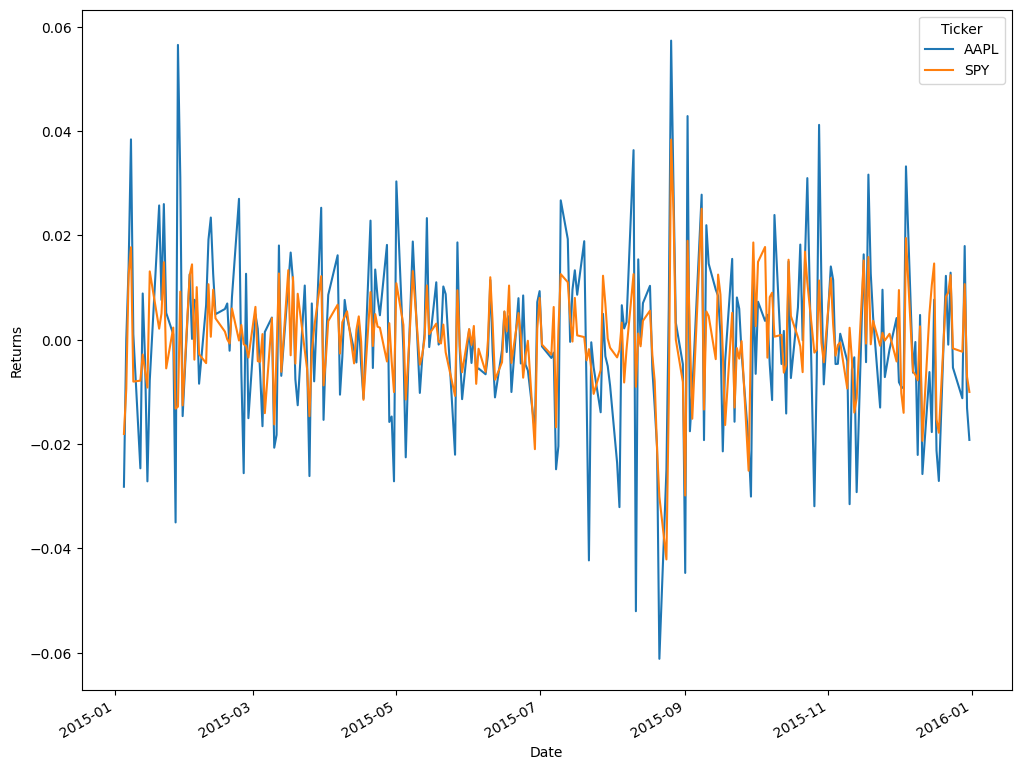

In [135]:
symbol_list = ["SPY", "AAPL"]

start, end = dt.datetime(2015, 1, 1), dt.datetime(2016, 1, 1)
pricing_sample=yf.download(symbol_list, start, end).loc[:,'Close']




returns_sample = pricing_sample.pct_change()[1:]
returns_sample.plot()
plt.ylabel('Returns')
print(returns_sample)

In [136]:
# Sample mean values
mu_spy = returns_sample['SPY'].mean()
mu_aapl=returns_sample['AAPL'].mean()
print(mu_spy)
print(mu_aapl)
# standard deviation
s_aapl = returns_sample['AAPL'].std()
s_spy = returns_sample['SPY'].std()
# sample sizes
n_spy = len(returns_sample['SPY'])
n_aapl = len(returns_sample['AAPL'])

#t-test 
# We suppose that both index have different variances

test_statistic = ((mu_spy - mu_aapl) - 0)/((s_spy**2/n_spy) + (s_aapl**2/n_aapl))**0.5

df = ((s_spy**2/n_spy) + (s_aapl**2/n_aapl))**2/(((s_spy**2 / n_spy)**2 /n_spy)+((s_aapl**2 / n_aapl)**2/n_aapl))

print('t test statistic: ', test_statistic)
print('Degrees of freedom (modified): ', df)


p_val = 2 * (1 - t.cdf(test_statistic, df))
print('P-value is: ', p_val)
# d'après la p_value on n'est pas en mesure de rejetter H_0

# t-test est connu sous le nom de Welch's unequal variances t-test.



9.833437162410472e-05
5.78952911326405e-05
t test statistic:  0.032894915272456964
Degrees of freedom (modified):  401.6758291254053
P-value is:  0.9737747268798784


#####  t-Test et valeurs critiques 

Notre Test-Statisque correspond à une loi de Student dont on connait le paramètre
on peut avoir un intervalle de confiance (comme pour le $z$-test ) et faire un test bilateral avec deux valeurs critiques. 

Comme $\alpha=0.05$ pour le test bilatéral partage en 0.025 des deux côtés et les valeurs critiques sont 

$t_{\text{critic},1}=F_t^{-1}(1-0.025)$

$t_{\text{critic},2}=F_t^{-1}(0.025)$

Si la valeur de Test_Statistique appartient l'intervalle $[t_{\text{critic},2},t_{\text{critic},1}]$ alors on ne peut pas rejeter $H_0$.

In [137]:

# valeurs critiques (test bilateral): 

test_statistic = ((mu_spy - mu_aapl) - 0)/((s_spy**2/n_spy) + (s_aapl**2/n_aapl))**0.5

print(test_statistic)

df = ((s_spy**2/n_spy) + (s_aapl**2/n_aapl))**2/(((s_spy**2 / n_spy)**2 /n_spy)+((s_aapl**2 / n_aapl)**2/n_aapl))

print('t test statistic: ', test_statistic)
print('Degrees of freedom (modified): ', df)


print(t.ppf(0.975, df), t.ppf(0.025, df))




0.032894915272456964
t test statistic:  0.032894915272456964
Degrees of freedom (modified):  401.6758291254053
1.9658874524974685 -1.965887452497469


La valeur $0.22 \in [-1.96;1.96]$ donc on n'est pas en mesure de rejeter l'hypothèse $H_0$, selon le $t$-test bilatéral. 

##### Conclusion 

La moyenne de rendement de Apple n'est pas significativement différente de celle de SP500.

## Test d'hypothèses sur les variances

Si nous voulons tester les variances de populations, nous devons utiliser une distribution différente des distributions $t$ et $z$. Les variances doivent, par définition, être supérieures à (ou égales à) $0$, et le fait que les distributions avec lesquelles nous avons travaillé jusqu'à présent permettent des valeurs négatives les rend inadaptées en tant que distributions de test. 

Au lieu des distributions $t$ et $z$, nous travaillerons avec les distributions $\chi^2$ pour les tests de variance simple et les distributions $F$ pour les comparaisons de variance. Ces distributions sont bornées en dessous par $0$, ce qui les rend adaptées aux tests de cette manière.

Tout comme avec tous nos autres tests d'hypothèses, les tests d'une seule variance peuvent prendre trois formes :

1. $H_0 : \sigma^2 = \sigma_0^2, \ H_A : \sigma^2 \neq \sigma_0^2$
2. $H_0 : \sigma^2 \leq \sigma_0^2, \ H_A : \sigma^2 > \sigma_0^2$
3. $H_0 : \sigma^2 \geq \sigma_0^2, \ H_A : \sigma^2 < \sigma_0^2$

La distribution $\chi^2$ est déterminée par le nombre de degrés de liberté. La forme de la distribution est différente pour chaque valeur différente du nombre de degrés de liberté, $k$.

In [138]:
from scipy.stats import chi2
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 12, 10

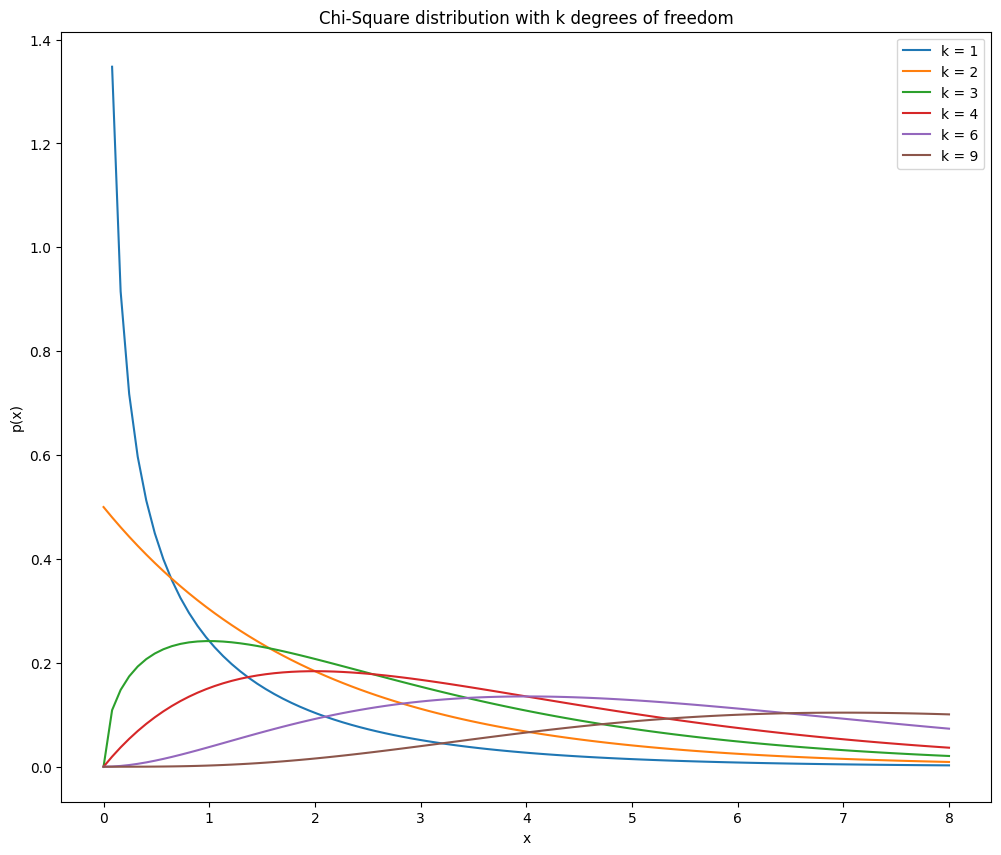

In [139]:
# Here we show what a chi-square looks like
x = np.linspace(0, 8, 100)
y_1 = chi2.pdf(x, 1)
y_2 = chi2.pdf(x, 2)
y_3 = chi2.pdf(x, 3)
y_4 = chi2.pdf(x, 4)
y_6 = chi2.pdf(x, 6)
y_9 = chi2.pdf(x, 9)


fig, ax = plt.subplots()
ax.plot(x, y_1, label = 'k = 1')
ax.plot(x, y_2, label = 'k = 2')
ax.plot(x, y_3, label = 'k = 3')
ax.plot(x, y_4, label = 'k = 4')
ax.plot(x, y_6, label = 'k = 6')
ax.plot(x, y_9, label = 'k = 9')
ax.legend()
plt.title('Chi-Square distribution with k degrees of freedom')
plt.xlabel('x')
plt.ylabel('p(x)');

Nous calculons la statistique de test $\chi^2$ comme suit :

$$ \chi^2 = \frac{(n - 1)s^2}{\sigma_0^2} $$

Où $s^2$ est la variance de l'échantillon et $n$ est la taille de l'ensemble de données. Le nombre de degrés de liberté est $n - 1$, et cela est utilisé en conjonction avec la statistique de test pour déterminer la (les) valeur(s) critique(s) de notre test d'hypothèse $\chi^2$.

C:\Users\lione\AppData\Local\Temp\ipykernel_42940\2958853591.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pricing_sample=yf.download('MSFT', start, end).loc[:,'Close']
[*********************100%***********************]  1 of 1 completed

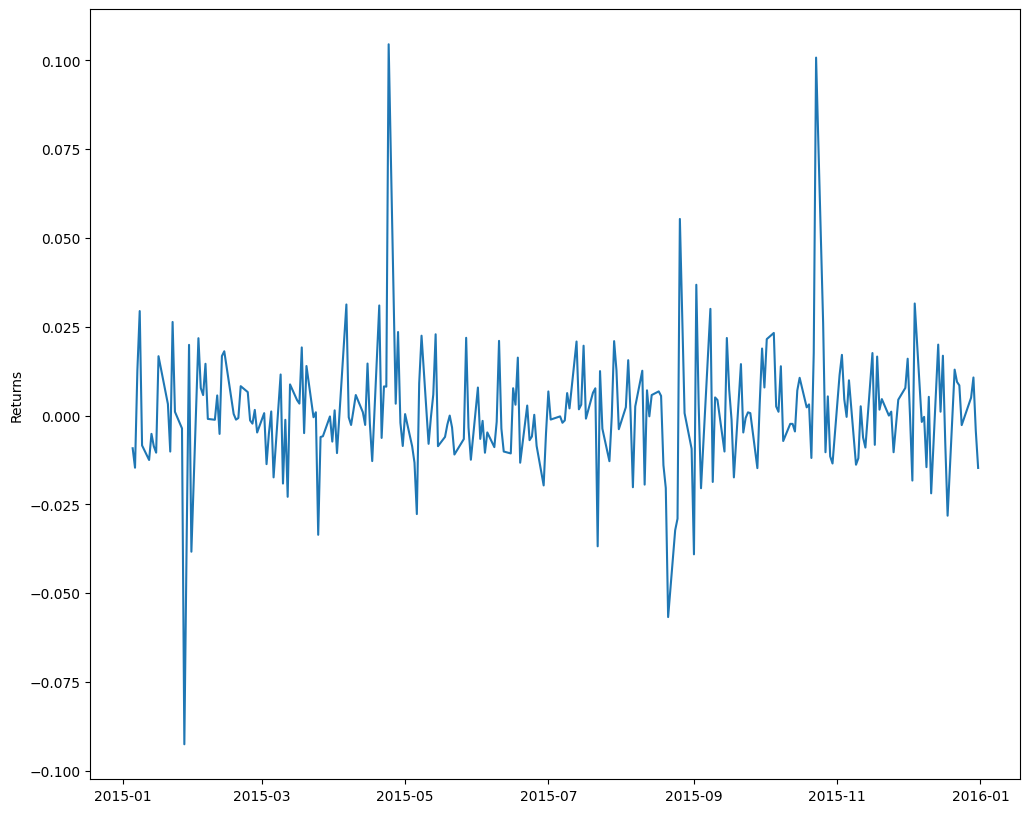

In [140]:

start, end = dt.datetime(2015, 1, 1), dt.datetime(2016, 1, 1)
pricing_sample=yf.download('MSFT', start, end).loc[:,'Close']

returns_sample = pricing_sample.pct_change()[1:]
plt.plot(returns_sample.index, returns_sample.values)
plt.ylabel('Returns');

Maintenant, nous allons utiliser un test $\chi^2$ pour évaluer la valeur de la variance de l'action Microsoft. Disons que nous voulons utiliser $\alpha = 0.01$ pour tester si la variance de MSFT est inférieure ou égale à $0.0001$ (c'est-à-dire que l'écart type, ou le risque, est inférieur ou égal à $0.01$).


\begin{align*}
&H_0: \sigma^2 \leq 0.0001 \\
&H_A: \sigma^2 > 0.0001
\end{align*}


Donc, maintenant, nous calculons notre statistique de test :

In [141]:
test_statistic = (len(returns_sample)-1)*returns_sample.var()/(0.0001)
print('Chi-square test statistic: ', test_statistic)

Chi-square test statistic:  Ticker
MSFT    792.096007
dtype: float64


In [142]:
# Here we calculate the critical value directly because our df is too high for most chisquare tables
crit_value = chi2.ppf(0.01, df=len(returns_sample)-1)
print('Critical value at a = 0.01 with 251 df: ', crit_value)

Critical value at a = 0.01 with 251 df:  200.93862345528606


Parce que nous utilisons la formulation « inférieure ou égale à » d'un test d'hypothèse unilatéral, nous rejetons l'hypothèse nulle si notre statistique de test est supérieure à la valeur critique. Puisque $795.328 > 200.938$, nous rejetons l'hypothèse nulle en faveur de l'alternative et affirmons que $\sigma^2 > 0.0001$.

### Comparaison de deux variances

Nous pouvons comparer les variances de deux éléments distincts en utilisant la distribution $F$ de FISCHER. Lors de la construction d'une comparaison de variances à l'aide d'un test $F$, les formulations d'hypothèses sont les suivantes (au cas où vous ne voulez pas faire défiler vers le haut) :

1. $H_0 : \sigma_1^2 = \sigma_2^2, \ H_A : \sigma_1^2 \neq \sigma_2^2$
2. $H_0 : \sigma_1^2 \leq \sigma_2^2, \ H_A : \sigma_1^2 > \sigma_2^2$
3. $H_0 : \sigma_1^2 \geq \sigma_2^2, \ H_A : \sigma_1^2 < \sigma_2^2$

La distribution $F$ est similaire à la distribution $\chi^2$ en ce qu'elle est asymétrique et bornée inférieurement par $0$. La distribution $F$ est définie avec deux valeurs différentes de degrés de liberté.  Une distribution $F$ peut être construite à partir de deux distributions $\chi^2$ distinctes. $X$ est une variable aléatoire $F$ si elle peut être écrite comme $X = \frac{Y_1/d_1}{Y_2/d_2}$, où $Y_1$ et $Y_2$ sont des variables aléatoires $\chi^2$ avec des degrés de liberté $d_1$ et $d_2$, respectivement.

Une variable aléatoire $F$ est essentiellement un rapport de variances. Par conséquent, la construction de la statistique de test $F$ se fait en prenant le rapport des variances échantillonnées des données que nous voulons tester. Nous pouvons simplement choisir $\sigma_1^2$ et $\sigma_2^2$ pour représenter l'une ou l'autre des variances que nous comparons afin que notre statistique F soit supérieure à $1$.

$$ F = \frac{s_1^2}{s_2^2} $$

Comparons SPY et AAPL pour voir si leurs variances sont les mêmes (un test d'hypothèse 'non égal à'). Nous utiliserons un test avec $\alpha = 0.05$. Rappelez-vous que pour un test bilatéral, nous calculons les valeurs critiques inférieure et supérieure en utilisant les valeurs de $\alpha/2$. Recueillons les données et calculons la statistique de test.


In [143]:
symbol_list = ["SPY", "AAPL"]
start, end = dt.datetime(2015, 1, 1), dt.datetime(2016, 1, 1)
pricing_sample=yf.download(symbol_list, start, end).loc[:,'Close']

returns_sample = pricing_sample.pct_change()[1:]
print(returns_sample)

C:\Users\lione\AppData\Local\Temp\ipykernel_42940\1871843737.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  pricing_sample=yf.download(symbol_list, start, end).loc[:,'Close']
[*********************100%***********************]  2 of 2 completed

Ticker          AAPL       SPY
Date                          
2015-01-05 -0.028171 -0.018060
2015-01-06  0.000094 -0.009419
2015-01-07  0.014022  0.012461
2015-01-08  0.038423  0.017745
2015-01-09  0.001072 -0.008013
...              ...       ...
2015-12-24 -0.005340 -0.001650
2015-12-28 -0.011201 -0.002285
2015-12-29  0.017974  0.010672
2015-12-30 -0.013059 -0.007088
2015-12-31 -0.019195 -0.010003

[251 rows x 2 columns]


In [144]:
# Take returns from above, AAPL and SPY, and compare their variances
aapl_std_dev, spy_std_dev = returns_sample.std()
print('SPY standard deviation is: ', spy_std_dev)
print('AAPL standard deviation is: ', aapl_std_dev)

SPY standard deviation is:  0.009740513410855169
AAPL standard deviation is:  0.016865756283980054


Notez que l'écart-type d'AAPL est supérieur à l'écart-type de SPY. Par conséquent, nous choisissons $\sigma_1^2$ pour représenter la variance d'AAPL et $\sigma_2^2$ pour représenter la variance de SPY.


In [145]:
test_statistic = (aapl_std_dev**2) / (spy_std_dev**2)
print("F Test statistic: ", test_statistic)

F Test statistic:  2.9981126262922846


In [146]:
# Since these values are taken over the same time period, they will have the same number of degrees of freedom
df1 = len(returns_sample['AAPL']) - 1
df2 = len(returns_sample['SPY']) - 1

print('Degrees of freedom for SPY: ', df2)
print('Degrees of freedom for AAPL: ', df1)

Degrees of freedom for SPY:  250
Degrees of freedom for AAPL:  250


In [147]:
from scipy.stats import f

In [148]:
upper_crit_value = f.ppf(0.975, df1, df2)
lower_crit_value = f.ppf(0.025, df1, df2)
print('Upper critical value at a = 0.05 with df1 = {0} and df2 = {1}: '.format(df1, df2), upper_crit_value)
print('Lower critical value at a = 0.05 with df1 = {0} and df2 = {1}: '.format(df1, df2), lower_crit_value)

Upper critical value at a = 0.05 with df1 = 250 and df2 = 250:  1.2820806494835295
Lower critical value at a = 0.05 with df1 = 250 and df2 = 250:  0.7799821332634866


Nous constatons que la valeur de notre statistique F est supérieure à la valeur critique supérieure pour notre test F. Ainsi, nous **rejetons** l'hypothèse nulle en faveur de l'alternative et concluons que les variances d'AAPL et de SPY diffèrent effectivement.
